# Actualización y estandarización recurrente de dependencias externas

In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path
src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

# Análisis exploratorio (EDA) - Distribución y análisis de datos
Dada la información extraída y almacenada en formato .parquet, se realiza un análisis exploratorio sobre la información recolectada

## Importación de librerias necesarias

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.utils import SparkUtils
from pyspark.sql import functions as F, types as T, DataFrame, Window
from pyspark.ml.feature import Tokenizer, StopWordsRemover
import json
import os

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [4]:
from src.utils.dataframe import check_null_values, check_empty_arrays

In [5]:
spark_utils = SparkUtils('eda')

In [6]:
spark = spark_utils.spark

In [7]:
REGENERATE_TABLES = False

## Análisis información de productos

### Cargar información de items

La información de items se encuentra en la zona de consumo bronze al ser una carga de información originalmente en formato .jsonl

In [8]:
meta_items = spark.read.format('delta').load(spark_utils.path('meta_items', 'bronze'))

### Unificar información de descripciones

In [32]:
if REGENERATE_TABLES:
    meta_items_descriptions_unified = (
        meta_items
            .withColumn(
                'description_colapsed',
                F.concat_ws('. ', F.col('description'))
            )
    )
    (
        meta_items_descriptions_unified.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('meta_items_descriptions_unified'))
    )
meta_items_descriptions_unified = spark.read.format('delta').load(spark_utils.path('meta_items_descriptions_unified'))

In [33]:
f"Cantidad de productos disponibles {meta_items_descriptions_unified.count():,}"

'Cantidad de productos disponibles 3,125,022'

#### Crear conjunto de datos con palabras separadas

In [34]:
from src.utils.preprocessors import CleanWords
clean_words = CleanWords()
descriptions_clean_words_tokenized = clean_words.transform_default_no_normalization(
    meta_items_descriptions_unified,
    input_column='description_colapsed', pre_tokenized_column='description_colapsed', output_column = 'description_words'
)

In [35]:
if REGENERATE_TABLES:
    (
        descriptions_clean_words_tokenized.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('descriptions_clean_words_tokenized'))
    )
descriptions_clean_words_tokenized = spark.read.format('delta').load(spark_utils.path('descriptions_clean_words_tokenized'))

#### Incluir cantidad de palabras tokenizadas

In [36]:
meta_items_descriptions_unified_words_clean_with_length = (
    descriptions_clean_words_tokenized
        .withColumn(
            'clean_words_length', F.size(F.col('description_words'))
        )
        .filter(
            (F.col('clean_words_length') > 0) &
            (F.col('description_words')[0] != F.lit(""))
        )
)

In [37]:
if REGENERATE_TABLES:
    (
        meta_items_descriptions_unified_words_clean_with_length.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_descriptions_unified_words_clean_with_length'))
    )
meta_items_descriptions_unified_words_clean_with_length = spark.read.format('delta').load(spark_utils.path('meta_items_descriptions_unified_words_clean_with_length'))

#### Rangos asociados a cantidad de palabras

In [38]:
meta_items_descriptions_unified_words_clean_with_length_count = (
    meta_items_descriptions_unified_words_clean_with_length
        .agg(
            F.min('clean_words_length').alias('min_words_length'),
            F.max('clean_words_length').alias('max_words_length'),
            F.mean('clean_words_length').alias('mean_words_length'),
            F.std('clean_words_length').alias('std_words_length'),
        )
        .toPandas()
        .values
)

In [39]:
meta_items_descriptions_unified_wors_boxplot_data = pd.DataFrame({
    "min": meta_items_descriptions_unified_words_clean_with_length_count[0][0],
    "max": meta_items_descriptions_unified_words_clean_with_length_count[0][1],
    "mean": meta_items_descriptions_unified_words_clean_with_length_count[0][2],
    "std": meta_items_descriptions_unified_words_clean_with_length_count[0][3],
}, index = [0])

In [40]:
meta_items_descriptions_unified_wors_boxplot_data

,min,max,mean,std
0,1.0,93079.0,125.35132,207.923066


In [41]:
meta_items_descriptions_unified_words_clean_with_length_sample = (
    meta_items_descriptions_unified_words_clean_with_length
        .select('clean_words_length')
        .toPandas()
        .values
)

In [42]:
f"Cantidad de productos con descripciones disponibles {meta_items_descriptions_unified_words_clean_with_length.count():,}"

'Cantidad de productos con descripciones disponibles 1,669,142'

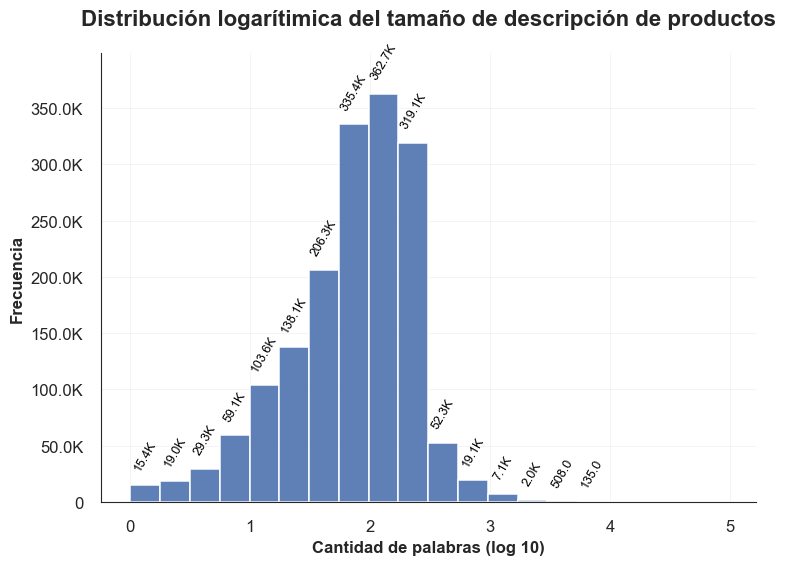

In [43]:
from src.utils.visualization.HistPlot import HistPlot
hist_plot = HistPlot(
    'Distribución logarítimica del tamaño de descripción de productos'
)
hist_plot.plot(
    np.log10(
        meta_items_descriptions_unified_words_clean_with_length_sample
            .reshape(meta_items_descriptions_unified_words_clean_with_length_sample.shape[0])
    ),
    bins = 20,
    xlabel = 'Cantidad de palabras (log 10)', ylabel = 'Frecuencia', decimal_points = 0,
    label_density = 0.8,
    rotate_labels = True,
    label_rotation = 60
)

### Unificar información de título

#### Crear conjunto de datos con palabras separadas y normalizadas

In [44]:
from src.utils.preprocessors import CleanWords
clean_words = CleanWords()
title_clean_words_tokenized = clean_words.transform_default_no_normalization(
    meta_items,
    input_column='title', pre_tokenized_column='title', output_column = 'title_words'
)

In [45]:
if REGENERATE_TABLES:
    (
        title_clean_words_tokenized.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('title_clean_words_tokenized'))
    )
title_clean_words_tokenized = spark.read.format('delta').load(spark_utils.path('title_clean_words_tokenized'))

#### Capturar largo de títulos en textos generales

In [46]:
meta_items_titles_unified_words_clean_with_length = (
    title_clean_words_tokenized
        .withColumn(
            'clean_words_length', F.size(F.col('title_words'))
        )
        .filter(
            (F.col('clean_words_length') > 0) &
            (F.col('title_words')[0] != F.lit(""))
        )
)

In [47]:
if REGENERATE_TABLES:
    (
        meta_items_titles_unified_words_clean_with_length.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_titles_unified_words_clean_with_length'))
    )
meta_items_titles_unified_words_clean_with_length = spark.read.format('delta').load(spark_utils.path('meta_items_titles_unified_words_clean_with_length'))

#### Distribución de largo de títulos en textos generales

In [48]:
meta_items_titles_unified_words_clean_with_length_count = (
    meta_items_titles_unified_words_clean_with_length
        .agg(
            F.min('clean_words_length').alias('min_words_length'),
            F.max('clean_words_length').alias('max_words_length'),
            F.mean('clean_words_length').alias('mean_words_length'),
            F.std('clean_words_length').alias('std_words_length'),
        )
        .toPandas()
        .values
)

In [49]:
meta_items_titles_unified_wors_boxplot_data = pd.DataFrame({
    "min": meta_items_titles_unified_words_clean_with_length_count[0][0],
    "max": meta_items_titles_unified_words_clean_with_length_count[0][1],
    "mean": meta_items_titles_unified_words_clean_with_length_count[0][2],
    "std": meta_items_titles_unified_words_clean_with_length_count[0][3],
}, index = [0])

In [50]:
meta_items_titles_unified_wors_boxplot_data

,min,max,mean,std
0,1.0,375.0,20.149857,9.255829


In [51]:
meta_items_titles_unified_words_clean_with_length_sample = (
        meta_items_titles_unified_words_clean_with_length
        .select('clean_words_length')
        .toPandas()
        .values
)

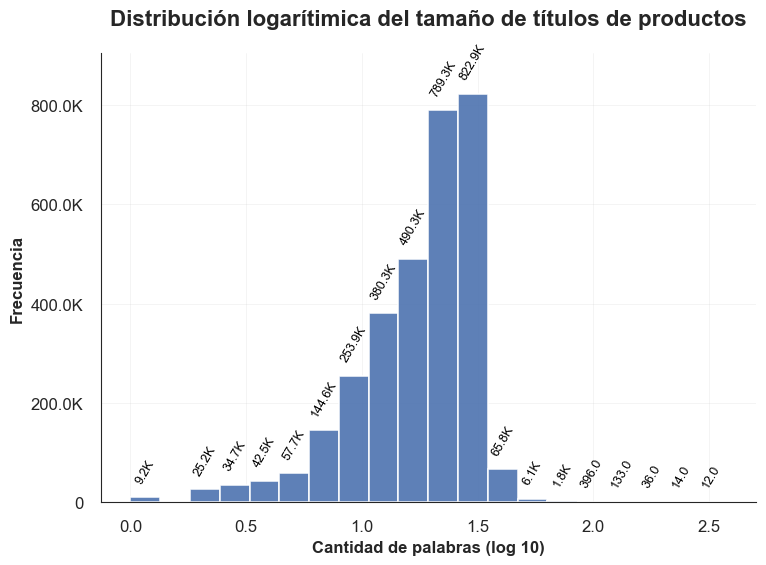

In [52]:
from src.utils.visualization.HistPlot import HistPlot
hist_plot = HistPlot(
    'Distribución logarítimica del tamaño de títulos de productos'
)
hist_plot.plot(
    np.log10(
        meta_items_titles_unified_words_clean_with_length_sample
            .reshape(meta_items_titles_unified_words_clean_with_length_sample.shape[0])
    ),
    bins = 20,
    xlabel = 'Cantidad de palabras (log 10)', ylabel = 'Frecuencia', decimal_points = 0,
    label_rotation = 60
)

### Unificar información de características (Campo Features)

In [53]:
if REGENERATE_TABLES:
    meta_items_features_unified = (
        meta_items
            .withColumn(
                'features_colapsed',
                F.concat_ws('. ', F.col('features'))
            )
    )
    (
        meta_items_features_unified.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('meta_items_features_unified'))
    )
meta_items_features_unified = spark.read.format('delta').load(spark_utils.path('meta_items_features_unified'))

#### Crear conjunto de datos con palabras separadas y normalizadas

In [54]:
from src.utils.preprocessors import CleanWords
clean_words = CleanWords()
features_clean_words_tokenized = clean_words.transform_default_no_normalization(
    meta_items_features_unified,
    input_column='features_colapsed', pre_tokenized_column='features_colapsed', output_column = 'features_words'
)

In [55]:
if REGENERATE_TABLES:
    (
        features_clean_words_tokenized.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('features_clean_words_tokenized'))
    )
features_clean_words_tokenized = spark.read.format('delta').load(spark_utils.path('features_clean_words_tokenized'))

#### Capturar largo de características definidas para productos

In [56]:
meta_items_features_unified_words_clean_with_length = (
    features_clean_words_tokenized
        .withColumn(
            'clean_words_length', F.size(F.col('features_words'))
        )
        .filter(
            (F.col('clean_words_length') > 0) &
            (F.col('features_words')[0] != F.lit(""))
        )
)

In [57]:
if REGENERATE_TABLES:
    (
        meta_items_features_unified_words_clean_with_length.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_features_unified_words_clean_with_length'))
    )
meta_items_features_unified_words_clean_with_length = spark.read.format('delta').load(spark_utils.path('meta_items_features_unified_words_clean_with_length'))

#### Distribución de largos de texto para características

In [58]:
meta_items_features_unified_words_clean_with_length_count = (
    meta_items_features_unified_words_clean_with_length
        .agg(
            F.min('clean_words_length').alias('min_words_length'),
            F.max('clean_words_length').alias('max_words_length'),
            F.mean('clean_words_length').alias('mean_words_length'),
            F.std('clean_words_length').alias('std_words_length'),
        )
        .toPandas()
        .values
)

In [59]:
meta_items_features_unified_wors_boxplot_data = pd.DataFrame({
    "min": meta_items_features_unified_words_clean_with_length_count[0][0],
    "max": meta_items_features_unified_words_clean_with_length_count[0][1],
    "mean": meta_items_features_unified_words_clean_with_length_count[0][2],
    "std": meta_items_features_unified_words_clean_with_length_count[0][3],
}, index = [0])

In [60]:
meta_items_features_unified_wors_boxplot_data

,min,max,mean,std
0,1.0,1342.0,101.611201,78.353064


In [61]:
meta_items_features_unified_words_clean_with_length_sample = (
    meta_items_features_unified_words_clean_with_length
        .select('clean_words_length')
        .toPandas()
        .values
)

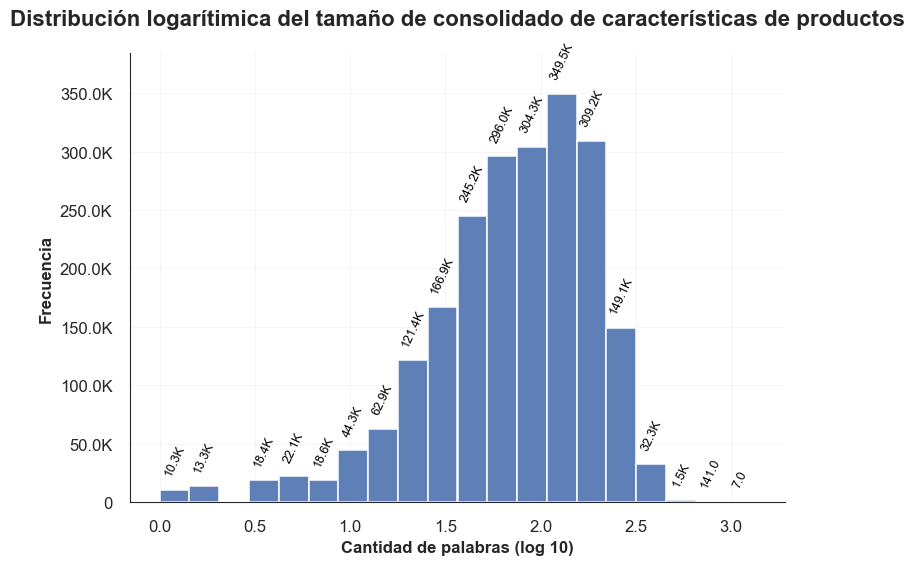

In [62]:
from src.utils.visualization.HistPlot import HistPlot
hist_plot = HistPlot(
    'Distribución logarítimica del tamaño de consolidado de características de productos'
)
hist_plot.plot(
    np.log10(
        meta_items_features_unified_words_clean_with_length_sample
            .reshape(meta_items_features_unified_words_clean_with_length_sample.shape[0])
    ),
    bins = 20,
    xlabel = 'Cantidad de palabras (log 10)', ylabel = 'Frecuencia', decimal_points = 0,
    label_rotation = 65
)

### Concatenación de distribución de características textuales

Grafica opcional para la presentación comparativa de características textuales

In [39]:
data_list = [
    {
        "values": np.log10(
            meta_items_descriptions_unified_words_clean_with_length_sample
                .reshape(meta_items_descriptions_unified_words_clean_with_length_sample.shape[0])
        ),
        "label": "Descripciones"
    },
    {
        "values": np.log10(
            meta_items_titles_unified_words_clean_with_length_sample
                .reshape(meta_items_titles_unified_words_clean_with_length_sample.shape[0])
        ),
        "label": "Títulos"
    },
    {
        "values": np.log10(
            meta_items_features_unified_words_clean_with_length_sample
                .reshape(meta_items_features_unified_words_clean_with_length_sample.shape[0])
        ),
        "label": "Características"
    }
]

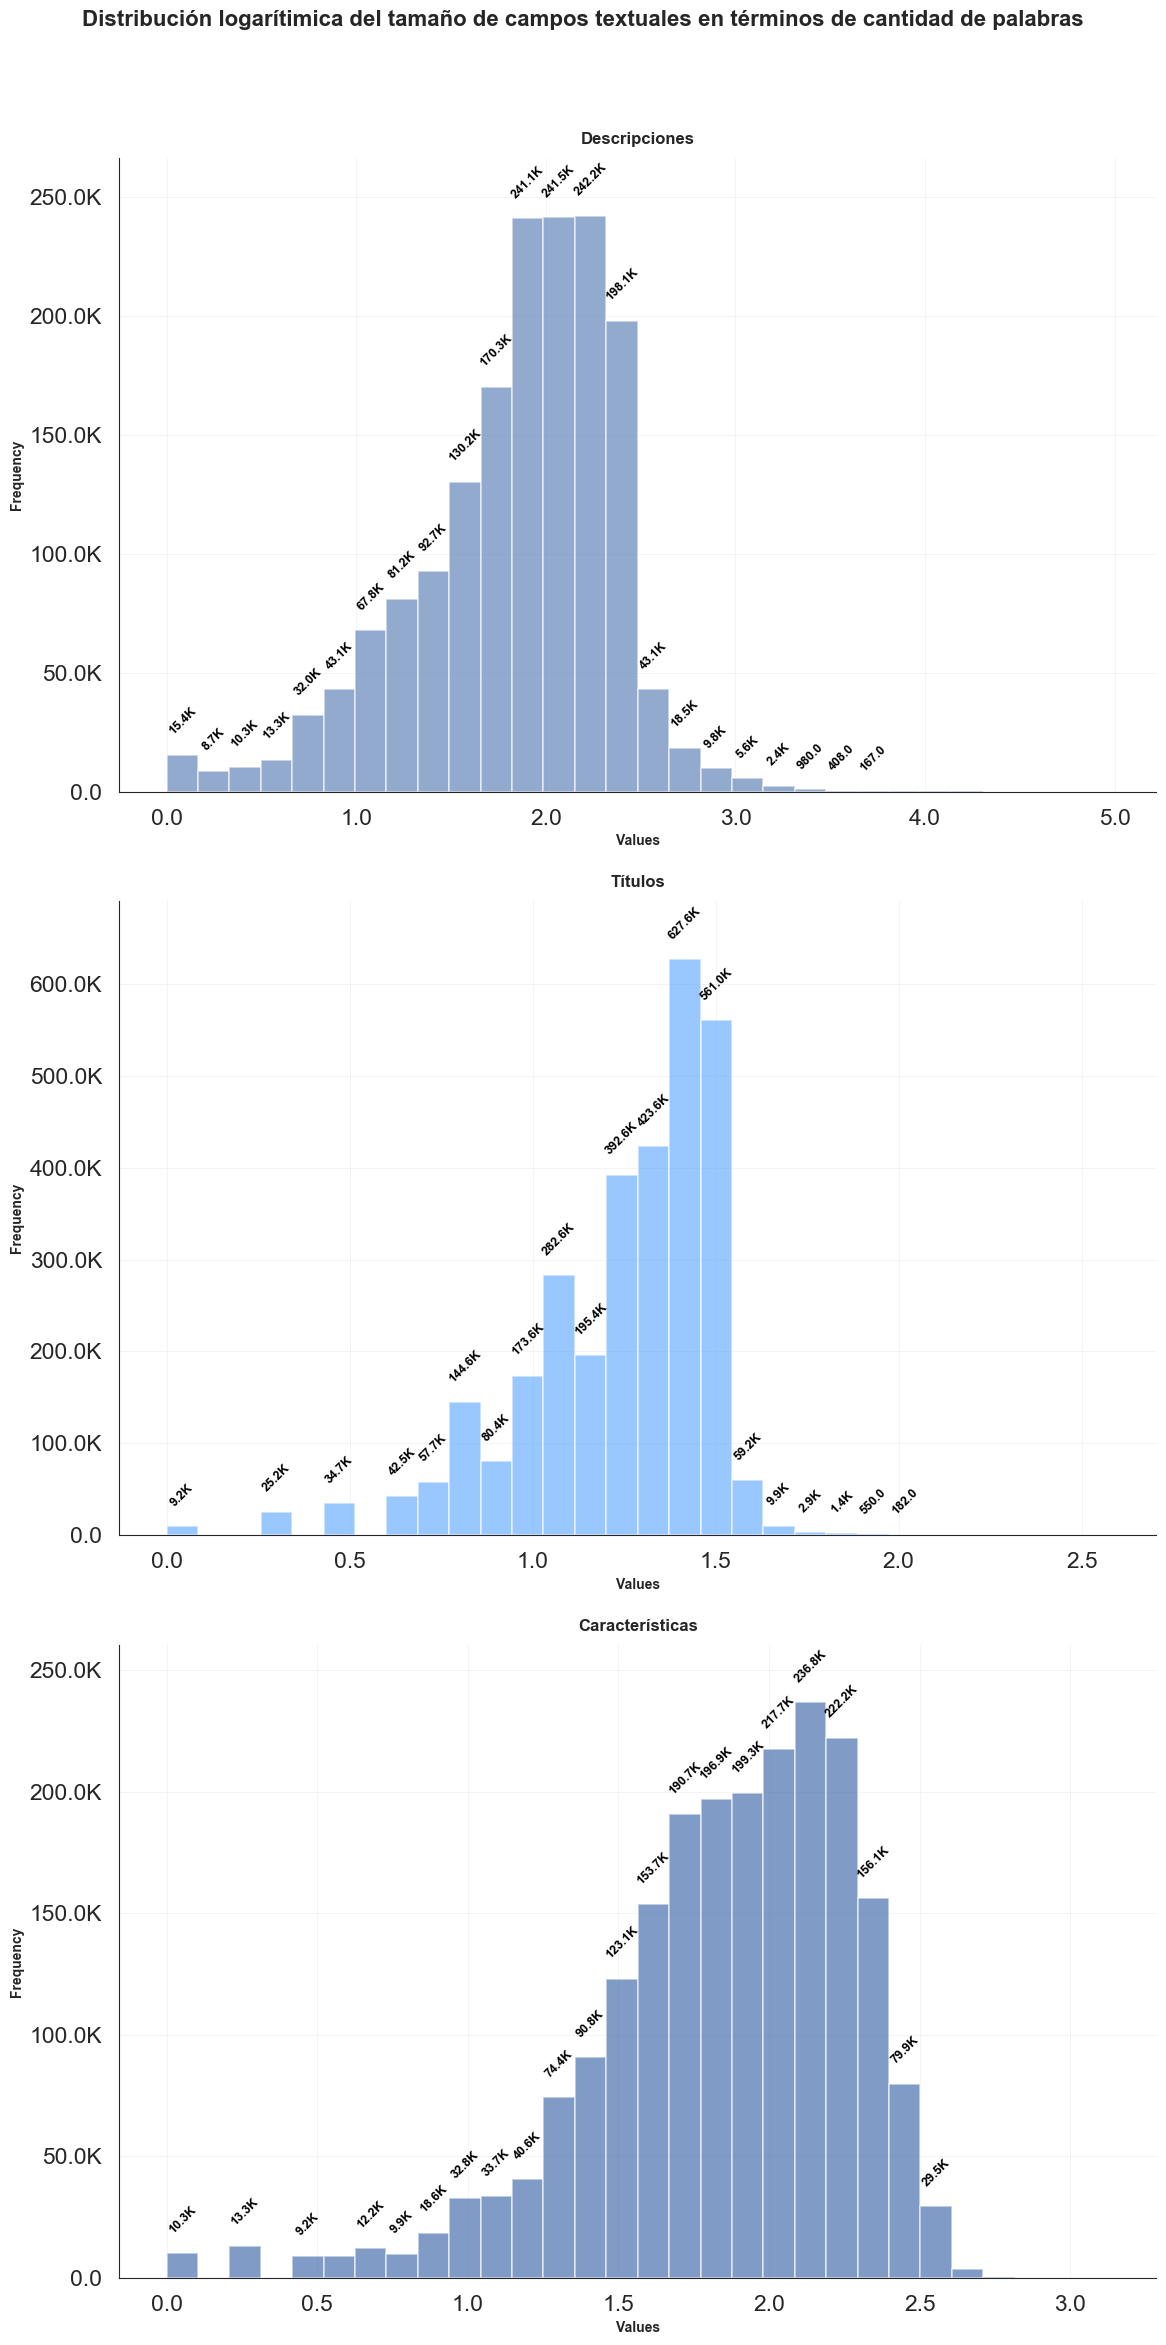

In [41]:
from src.utils.visualization.HistPlot import MultiHistPlot
multi_hist = MultiHistPlot("Distribución logarítimica del tamaño de campos textuales en términos de cantidad de palabras")
multi_hist.plot(
    data_list=data_list,
    bins=30,
    xlabel="Values",
    ylabel="Frequency",
    figsize=(12, 8),
    alpha=0.6,
    show_legend=True,
    legend_loc="upper right",
    layout = 'vertical',
    rotate_labels = True,
    label_density = 0.8
)


### Unificar información textual de componentes separados para productos

In [63]:
meta_items_texts = (
    meta_items.alias('A')
        .join(
            meta_items_descriptions_unified_words_clean_with_length.alias('B'),
            F.col('A.parent_asin') == F.col('B.parent_asin'),
            'left'
        )
        .join(
            meta_items_titles_unified_words_clean_with_length.alias('C'),
            F.col('A.parent_asin') == F.col('C.parent_asin'),
            'left'
        )
        .join(
            meta_items_features_unified_words_clean_with_length.alias('D'),
            F.col('A.parent_asin') == F.col('D.parent_asin'),
            'left'
        )
        .select(
            F.col('A.*'),
            F.col('B.description_colapsed'),
            F.col('D.features_colapsed'),
            F.format_string(
                "%s\n%s\n%s",
                F.when( F.col('B.description_colapsed').isNull(), F.lit('')).otherwise(F.col('B.description_colapsed')),
                F.when( F.col('C.title').isNull(), F.lit('')).otherwise(F.col('C.title')),
                F.when( F.col('D.features_colapsed').isNull(), F.lit('')).otherwise(F.col('D.features_colapsed')),
            ).alias('colapsed_text')
        )
)

In [64]:
if REGENERATE_TABLES:
    (
        meta_items_texts.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_texts'))
    )
meta_items_texts = spark.read.format('delta').load(spark_utils.path('meta_items_texts'))

In [44]:
tokenizer = Tokenizer(inputCol="colapsed_text", outputCol="words")
tokenized = tokenizer.transform(meta_items_texts)
remover = StopWordsRemover(inputCol="words", outputCol="clean_words")
meta_items_texts_words = remover.transform(tokenized)

In [45]:
from src.utils.preprocessors import CleanWords
clean_words = CleanWords()
meta_items_texts_tokenized = clean_words.tokenize(
    meta_items_texts,
    input_column='colapsed_text', output_column = 'colapsed_text_words'
)

In [46]:
if REGENERATE_TABLES:
    (
        meta_items_texts_tokenized.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('meta_items_texts_tokenized'))
    )
meta_items_texts_tokenized = spark.read.format('delta').load(spark_utils.path('meta_items_texts_tokenized'))

In [47]:
meta_items_texts_tokenized_with_length = (
    meta_items_texts_tokenized
        .withColumn(
            'colapsed_text_length', F.size(F.col('colapsed_text_words'))
        )
        .filter(
            (F.col('colapsed_text_length') > 0) &
            (F.col('colapsed_text_words')[0] != F.lit(""))
        )
)

In [48]:
meta_items_texts_tokenized_with_length_sample = (
    meta_items_texts_tokenized_with_length
        .select('colapsed_text_length')
        .toPandas()
        .values
)

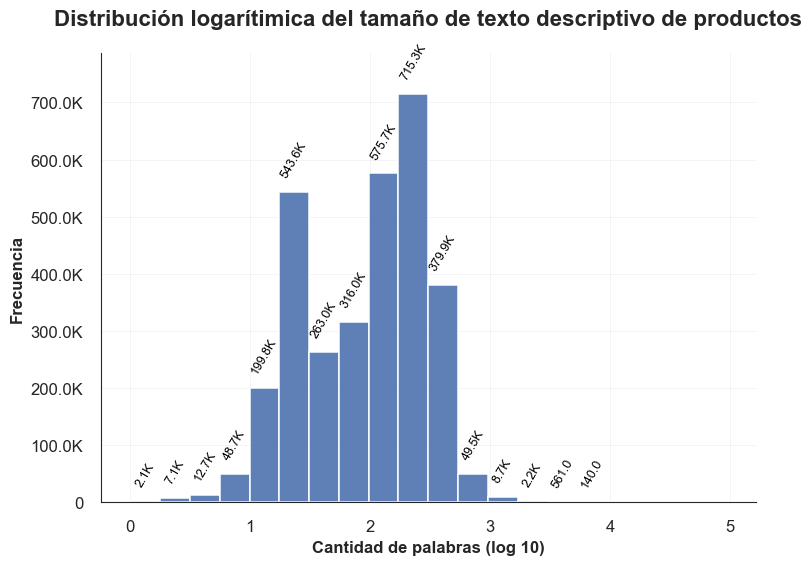

In [49]:
from src.utils.visualization.HistPlot import HistPlot
hist_plot = HistPlot(
    'Distribución logarítimica del tamaño de texto descriptivo de productos'
)
hist_plot.plot(
    np.log10(
        meta_items_texts_tokenized_with_length_sample
            .reshape(meta_items_texts_tokenized_with_length_sample.shape[0])
    ),
    bins = 20,
    xlabel = 'Cantidad de palabras (log 10)', ylabel = 'Frecuencia', decimal_points = 0,
    label_density = 0.8,
    rotate_labels = True,
    label_rotation = 60
)

#### Revisión de cantidades de producto con una cantidad de tokens dada

In [50]:
meta_items_texts_tokenized_with_length.filter(
    F.col('colapsed_text_length') > 50
).count()

2074567

#### Cálculo de TTR

In [51]:
exploded = meta_items_texts_tokenized.withColumn(
    "token", F.explode("colapsed_text_words")
)
unique_counts = exploded.groupBy("parent_asin").agg(
    F.count("token").alias("token_count"),
    F.countDistinct("token").alias("unique_token_count")
)
meta_items_ttr = unique_counts \
    .withColumn("TTR", F.col("unique_token_count") / F.col("token_count"))

In [52]:
if REGENERATE_TABLES:
    (
        meta_items_ttr.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_ttr'))
    )
meta_items_ttr = spark.read.format('delta').load(spark_utils.path('meta_items_ttr'))

In [53]:
meta_items_ttr_sample = (
    meta_items_ttr
        .select('TTR')
        .toPandas()
        .values
)

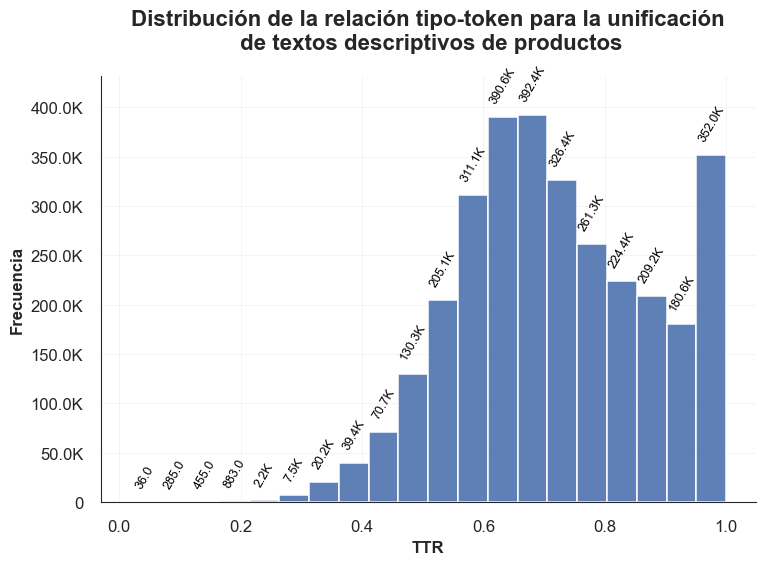

In [54]:
from src.utils.visualization.HistPlot import HistPlot
hist_plot = HistPlot(
    'Distribución de la relación tipo-token para la unificación\n de textos descriptivos de productos'
)
hist_plot.plot(
        meta_items_ttr_sample
            .reshape(meta_items_ttr_sample.shape[0])
    ,
    bins = 20,
    xlabel = 'TTR', ylabel = 'Frecuencia', decimal_points = 0
)

### Revisión de campo detalles

Llaves principales usadas en el campo detalles

In [55]:
def get_json_keys(str_obj):
    obj : dict = json.loads(str_obj)
    keys = list(obj.keys())
    return keys
meta_items_json_keys = (
    meta_items
        .select(
            F.col('*'),
            F.explode(
                F.udf(
                    get_json_keys, T.ArrayType(T.StringType())
                )(F.col('details'))
            ).alias('item')
        )
)

In [56]:
meta_items_json_keys_counts = (
    meta_items_json_keys
        .groupBy('item')
        .agg(F.count('*').alias('count'))
        .orderBy(F.col('count').desc())
        .withColumn(
            'count_index',
            F.row_number().over(
                Window
                    .orderBy(
                        F.col('count').desc()
                    )
            )
        )
        .withColumn(
            'item',
            F.when(
                F.col('count_index') > F.lit(15),
                F.lit('Otro')
            ).otherwise(F.col('item'))
        )
        .groupBy('item')
        .agg(F.sum('count').alias('count'))
        .orderBy(F.col('count').desc())
        .withColumn(
            'count_index',
            F.row_number().over(
                Window
                    .orderBy(
                        F.col('count').desc()
                    )
            )
        )
        .withColumn(
            'count_percentage',
            F.col('count') * 100 / meta_items_json_keys.count()
        )
        .withColumn(
            "label",
            F.format_string("%s (%.2f %%)", F.col('item'), F.col('count_percentage'))
        )
        .toPandas()
)

In [57]:
df_meta_items_json_keys_counts = {
    "values": meta_items_json_keys_counts["count_percentage"],
    "labels": meta_items_json_keys_counts["label"],
}

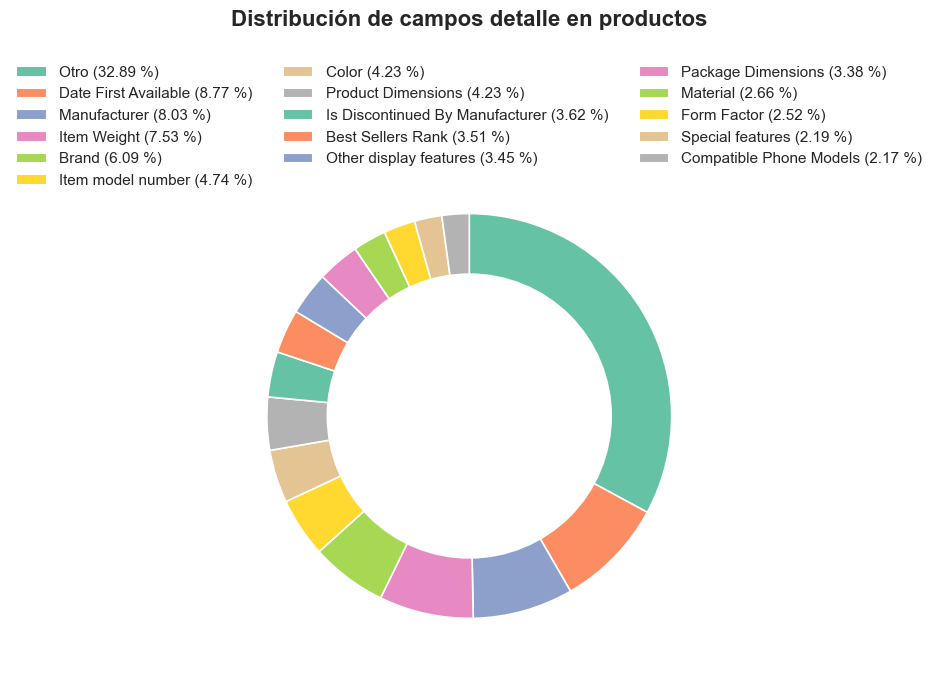

In [58]:
from src.utils.visualization.CircularPlot import CircularPlot
circular_plot = CircularPlot()
circular_plot.prepare_single_show(
    title = "Distribución de campos detalle en productos",
)
circular_plot.plot(
    df_meta_items_json_keys_counts["values"],
    legend_labels = df_meta_items_json_keys_counts["labels"],
    n_col=3, col_size = 7, rows_size = 7,
    plot_rect = [0,0,1,0.8],
    legend_y = 0.92,
)

In [59]:
meta_items_details_grouped_by_category = (
    meta_items_json_keys
        .groupBy('main_category', 'item')
        .agg(F.count('*').alias('item_count'))
)
meta_items_details_grouped_by_category_top = (
    meta_items_details_grouped_by_category
        .groupBy('main_category')
        .agg(F.sum('item_count').alias('category_count'))
        .withColumn(
            'category_count_rank',
            F.row_number().over(
                Window
                    .orderBy(F.col('category_count').desc())
            )
        )
        .filter(F.col('category_count_rank') <= 4)
)
meta_items_details_grouped_by_category_top_and_item = (
    meta_items_details_grouped_by_category.alias('A')
        .join(
            meta_items_details_grouped_by_category_top.alias('B'),
            (F.col('A.main_category') == F.col('B.main_category')),
            'inner'
        )
        .select(F.col('A.*'))
        .withColumn(
            'item_count_rank',
            F.row_number().over(
                Window
                    .partitionBy(F.col('main_category'))
                    .orderBy(F.col('item_count').desc())
            )
        )
        .filter(F.col('item_count_rank') <= 10)
)
meta_items_details_grouped_by_category_top_and_item_grouped = (
    meta_items_details_grouped_by_category_top_and_item
        .groupBy('main_category')
        .agg(
            F.collect_list(
                F.array(
                    F.col('item'), F.col('item_count')
                )
            ).alias('item_data')
        )
)

In [60]:
df_meta_items_details_grouped_by_category_top_and_item_grouped = (
    meta_items_details_grouped_by_category_top_and_item_grouped
        .toPandas()
        .values
)

In [61]:
def build_dict(x):
    return {
        "values": list(map(lambda y: int(y[1]), x[1])),
        "labels": list(map(lambda y: y[0], x[1])),
        "title": f"{x[0]}"
    }
lst_meta_items_details_grouped_by_category_top_and_item_grouped = list(map(
    lambda x: build_dict(x),
    df_meta_items_details_grouped_by_category_top_and_item_grouped
))

In [66]:
from src.utils.visualization.Barplot import BarPlot
barplot = BarPlot()
barplot.prepare_matrix_show(
    title = "Participación de detalles de producto por categoría principal",
    cols = 1
)
barplot.plot(
    lst_meta_items_details_grouped_by_category_top_and_item_grouped,
    ylabel = "Porcentaje (%)", is_percentage = False, decimal_points = 0,
    x_rotation=0, 
    y_rotation=0
)

NameError: name 'lst_meta_items_details_grouped_by_category_top_and_item_grouped' is not defined

### Subcategorías de producto disponibles

In [63]:
meta_items_main_categories_grouped = (
    meta_items
        .filter(F.col('main_category').isNotNull())
        .groupBy('main_category')
        .agg(F.count('*').alias('count'))
)

In [64]:
meta_items_main_categories_counts = (
    meta_items_main_categories_grouped
        .withColumn(
            'count_index',
            F.row_number().over(
                Window
                    .orderBy(
                        F.col('count').desc()
                    )
            )
        )
        .withColumn(
            'main_category',
            F.when(
                F.col('count_index') > F.lit(15),
                F.lit('Otro')
            ).otherwise(F.col('main_category'))
        )
        .groupBy('main_category')
        .agg(F.sum('count').alias('count'))
        .orderBy(F.col('count').desc())
        .withColumn(
            'count_index',
            F.row_number().over(
                Window
                    .orderBy(
                        F.col('count').desc()
                    )
            )
        )
        .withColumn(
            'count_percentage',
            F.col('count') * 100 / F.sum('count').over(
                Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)
            )
        )
        .withColumn(
            "label",
            F.format_string("%s (%.2f %%)", F.col('main_category'), F.col('count_percentage'))
        )
)

In [65]:
meta_items_main_categories_counts_sample = (
    meta_items_main_categories_counts.toPandas()
)

In [66]:
meta_items_main_categories_counts_sample

,main_category,count,count_index,count_percentage,label
0,Cell Phones & Accessories,1187766,1,41.050137,Cell Phones & Accessories (41.05 %)
1,Computers,444322,2,15.356121,Computers (15.36 %)
2,All Electronics,439060,3,15.174262,All Electronics (15.17 %)
3,Camera & Photo,229474,4,7.930804,Camera & Photo (7.93 %)
4,Home Audio & Theater,109955,5,3.800132,Home Audio & Theater (3.80 %)
5,Video Games,82756,6,2.860113,Video Games (2.86 %)
6,Otro,81063,7,2.801602,Otro (2.80 %)
7,Appstore for Android,68679,8,2.373601,Appstore for Android (2.37 %)
8,Industrial & Scientific,56999,9,1.969931,Industrial & Scientific (1.97 %)
9,AMAZON FASHION,47746,10,1.650140,AMAZON FASHION (1.65 %)


In [67]:
df_meta_items_main_categories_counts = {
    "values": meta_items_main_categories_counts_sample["count_percentage"],
    "labels": meta_items_main_categories_counts_sample["label"],
}

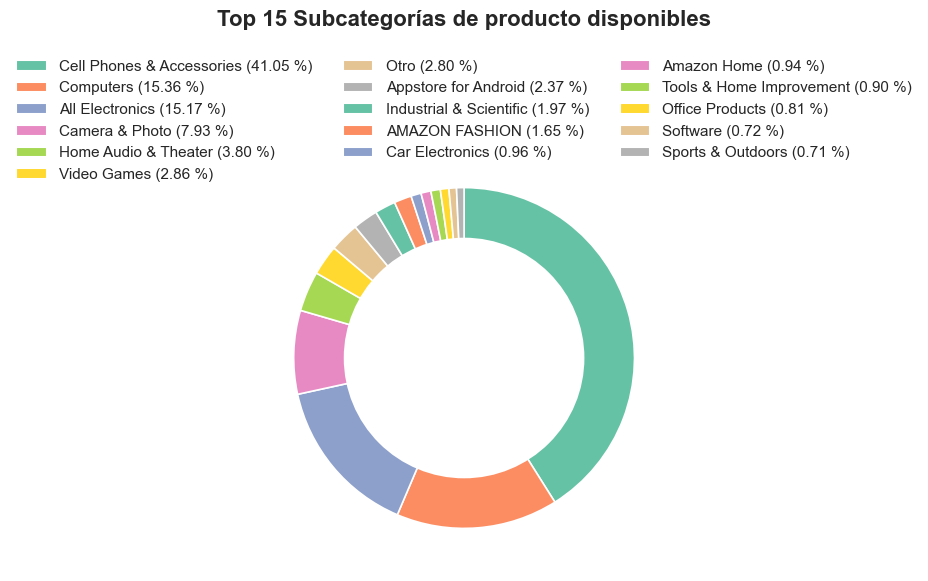

In [68]:
from src.utils.visualization.CircularPlot import CircularPlot
circular_plot = CircularPlot()
circular_plot.prepare_single_show(
    title = "Top 15 Subcategorías de producto disponibles",
)
circular_plot.plot(
    df_meta_items_main_categories_counts["values"],
    legend_labels = df_meta_items_main_categories_counts["labels"],
    n_col=3,
    col_size = 6, rows_size = 6,
    plot_rect = [0,0,1,0.8],
    legend_y = 0.92,
)

Lista de subcategorías de producto disponibles

In [69]:
meta_items_main_categories_grouped.orderBy(F.col('count').desc()).toPandas()

,main_category,count
0,Cell Phones & Accessories,1187766
1,Computers,444322
2,All Electronics,439060
3,Camera & Photo,229474
4,Home Audio & Theater,109955
5,Video Games,82756
6,Appstore for Android,68679
7,Industrial & Scientific,56999
8,AMAZON FASHION,47746
9,Car Electronics,27884


## Análisis información de reseñas

### Cargar información de items

In [70]:
reviews = spark.read.format('delta').load(spark_utils.path('reviews', 'bronze'))

In [71]:
if REGENERATE_TABLES:
    reviews_with_products = (
        reviews.alias('A')
            .join(
                meta_items_texts.alias('B'),
                F.col('A.parent_asin') == F.col('B.parent_asin')
            )
            .select(
                F.col('A.rating'), F.col('A.title').alias('review_title'),
                F.col('A.text').alias('review_text'), F.col('A.timestamp'),
                F.col('A.helpful_vote'),
                'B.*',
            )
    )
    (
        reviews_with_products.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('reviews_with_products'))
    )
reviews_with_products = spark.read.format('delta').load(spark_utils.path('reviews_with_products'))

### Distribución de puntuación

In [72]:
reviews_rating_with_categories = (
    reviews_with_products
        .groupBy('main_category')
        .agg(
            F.min('rating').alias('min_rating'),
            F.max('rating').alias('max_rating'),
            F.mean('rating').alias('mean_rating'),
            F.std('rating').alias('std_rating'),
        )
        .toPandas()
        .values
)

In [73]:
reviews_rating_distribution = (
    reviews_with_products
        .groupBy('rating')
        .agg(F.count('*').alias('count'))
        .orderBy('rating')
        .toPandas()
)
reviews_rating_barplot_data = {
    "values": reviews_rating_distribution["count"].values,
    "labels": [f"{int(rating)}" for rating in reviews_rating_distribution["rating"].values]
}
reviews_rating_stats = (
    reviews_with_products
        .agg(
            F.min('rating').alias('min_rating'),
            F.max('rating').alias('max_rating'),
            F.mean('rating').alias('mean_rating'),
            F.std('rating').alias('std_rating'),
            F.count('rating').alias('total_reviews')
        )
        .toPandas()
        .values[0]
)
print("Estadísticas de calificaciones:")
print(f"Calificación mínima: {reviews_rating_stats[0]}")
print(f"Calificación máxima: {reviews_rating_stats[1]}")
print(f"Calificación promedio: {reviews_rating_stats[2]:.2f}")
print(f"Desviación estándar: {reviews_rating_stats[3]:.2f}")
print(f"Total de reseñas: {reviews_rating_stats[4]:,}")


Estadísticas de calificaciones:
Calificación mínima: 0.0
Calificación máxima: 5.0
Calificación promedio: 4.06
Desviación estándar: 1.43
Total de reseñas: 74,204,685.0


d:\Maestría\Amazon Reviews Code\src\utils\visualization\Barplot.py:314: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels)


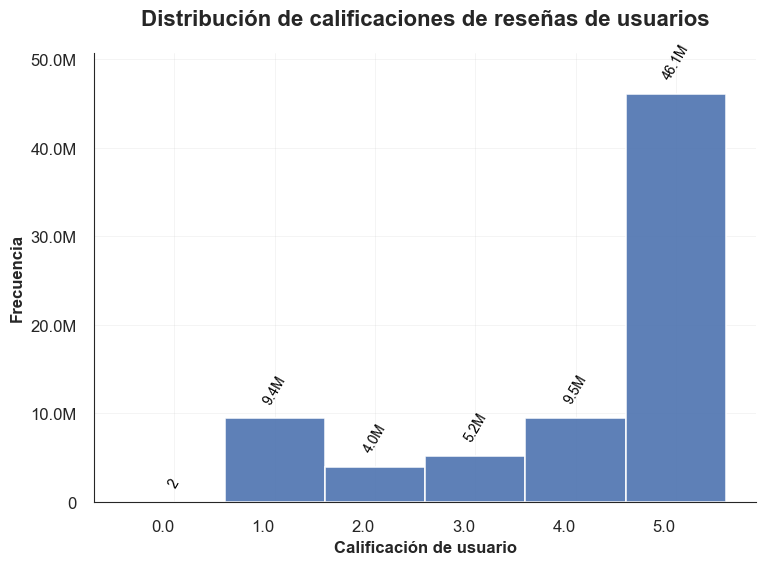

In [74]:
from src.utils.visualization.Barplot import BarPlot
bar_plot_rating = BarPlot()
bar_plot_rating.prepare_single_show(
    title='Distribución de calificaciones de reseñas de usuarios'
)
bar_plot_rating.plot(
    reviews_rating_barplot_data,
    ylabel='Frecuencia', 
    xlabel='Calificación de usuario',
    decimal_points=0,
    is_percentage=False, 
    x_rotation=0, 
    y_rotation=0
)


### Revisión frecuencia de palabras en reseñas

In [75]:
from src.utils.preprocessors import CleanWords
clean_words = CleanWords()
reviews_clean_words_clean_html = clean_words.clean_html(
    reviews,
    "text"
)
reviews_clean_words_clean_emojis = clean_words.separate_emojis(
    reviews_clean_words_clean_html,
    "text"
)
reviews_clean_words_tokenized = clean_words.tokenize(
    reviews_clean_words_clean_emojis,
    input_column='text', output_column = 'review_words'
)

In [76]:
if REGENERATE_TABLES:
    (
        reviews_clean_words_tokenized.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('reviews_clean_words_tokenized'))
    )
reviews_clean_words_tokenized = spark.read.format('delta').load(spark_utils.path('reviews_clean_words_tokenized'))

In [77]:
reviews_clean_words_with_length = (
    reviews_clean_words_tokenized
        .withColumn(
            'clean_words_length', F.size(F.col('review_words'))
        )
        .filter(
            (F.col('clean_words_length') > 0) &
            (F.col('review_words')[0] != F.lit(""))
        )
)

In [78]:
if REGENERATE_TABLES:
    (
        reviews_clean_words_with_length.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('reviews_clean_words_with_length'))
    )
reviews_clean_words_with_length = spark.read.format('delta').load(spark_utils.path('reviews_clean_words_with_length'))

In [79]:
reviews_text_length_stats = (
    reviews_clean_words_with_length
        .agg(
            F.min('clean_words_length').alias('min_words_length'),
            F.max('clean_words_length').alias('max_words_length'),
            F.mean('clean_words_length').alias('mean_words_length'),
            F.std('clean_words_length').alias('std_words_length'),
            F.count('clean_words_length').alias('total_reviews')
        )
        .toPandas()
        .values[0]
)
print("Estadísticas de longitudes de texto en reseñas:")
print(f"Longitud mínima: {reviews_text_length_stats[0]} palabras")
print(f"Longitud máxima: {reviews_text_length_stats[1]} palabras")
print(f"Longitud promedio: {reviews_text_length_stats[2]:.2f} palabras")
print(f"Desviación estándar: {reviews_text_length_stats[3]:.2f} palabras")
print(f"Total de reseñas: {reviews_text_length_stats[4]:,}")


Estadísticas de longitudes de texto en reseñas:
Longitud mínima: 1.0 palabras
Longitud máxima: 6204.0 palabras
Longitud promedio: 40.84 palabras
Desviación estándar: 71.01 palabras
Total de reseñas: 74,137,276.0


In [80]:
reviews_length_distribution = (
    reviews_clean_words_with_length
        .groupBy('clean_words_length')
        .agg(F.count('*').alias('count'))
        .orderBy('clean_words_length')
        .toPandas()
)
def create_length_ranges(df, bin_size=50):
    """Crear rangos de longitudes para visualización"""
    max_length = df['clean_words_length'].max()
    ranges = []
    counts = []
    for i in range(0, int(max_length) + bin_size, bin_size):
        range_end = min(i + bin_size - 1, max_length)
        range_label = f"{i}-{range_end}"
        count = df[
            (df['clean_words_length'] >= i) & 
            (df['clean_words_length'] <= range_end)
        ]['count'].sum()
        if count > 0:
            ranges.append(range_label)
            counts.append(count)
    return ranges, counts
length_ranges, length_counts = create_length_ranges(reviews_length_distribution, bin_size=50)
reviews_length_barplot_data = {
    "values": length_counts,
    "labels": length_ranges
}


In [ ]:
length_stats = reviews_clean_words_with_length.agg(
    F.min('clean_words_length').alias('min_length'),
    F.max('clean_words_length').alias('max_length')
).toPandas().iloc[0]
min_length = int(length_stats['min_length'])
max_length = int(length_stats['max_length'])
print(f"Longitud mínima de palabras: {min_length}")
print(f"Longitud máxima de palabras: {max_length}")


Longitud mínima de palabras: 1
Longitud máxima de palabras: 6204


In [82]:
import numpy as np
num_bins_reduced = 10
reviews_with_bins_reduced = (
    reviews_clean_words_with_length
        .withColumn(
            'log_length',
            F.log10(F.col('clean_words_length'))
        )
        .withColumn(
            'length_bin',
            F.floor((F.col('log_length') - F.log10(F.lit(min_length))) / ((F.log10(F.lit(max_length)) - F.log10(F.lit(min_length))) / num_bins_reduced))
        )
        .withColumn(
            'bin_start_log',
            F.floor((F.col('log_length') - F.log10(F.lit(min_length))) / ((F.log10(F.lit(max_length)) - F.log10(F.lit(min_length))) / num_bins_reduced)) * ((F.log10(F.lit(max_length)) - F.log10(F.lit(min_length))) / num_bins_reduced) + F.log10(F.lit(min_length))
        )
        .withColumn(
            'bin_end_log',
            F.floor((F.col('log_length') - F.log10(F.lit(min_length))) / ((F.log10(F.lit(max_length)) - F.log10(F.lit(min_length))) / num_bins_reduced)) * ((F.log10(F.lit(max_length)) - F.log10(F.lit(min_length))) / num_bins_reduced) + F.log10(F.lit(min_length)) + ((F.log10(F.lit(max_length)) - F.log10(F.lit(min_length))) / num_bins_reduced)
        )
        .withColumn(
            'bin_start',
            F.pow(F.lit(10), F.col('bin_start_log'))
        )
        .withColumn(
            'bin_end',
            F.pow(F.lit(10), F.col('bin_end_log'))
        )
        .withColumn(
            'bin_mean',
            (F.col('bin_start') + F.col('bin_end')) / 2
        )
        .withColumn(
            'bin_label',
            F.format_string("%.1f", F.col('bin_mean'))
        )
)
reviews_length_distribution_reduced = (
    reviews_with_bins_reduced
        .groupBy('bin_label', 'bin_start', 'bin_mean')
        .agg(F.count('*').alias('count'))
        .orderBy('bin_start')
        .toPandas()
)
reviews_length_barplot_data_reduced = {
    "values": reviews_length_distribution_reduced['count'].values,
    "labels": reviews_length_distribution_reduced['bin_label'].values
}
print(f"Distribución reducida con {len(reviews_length_distribution_reduced)} rangos")
print("Etiquetas del eje X:", reviews_length_distribution_reduced['bin_label'].tolist())


Distribución reducida con 11 rangos
Etiquetas del eje X: ['1.7', '4.1', '9.7', '23.3', '55.8', '133.7', '320.2', '766.7', '1836.2', '4397.3', '10530.6']


d:\Maestría\Amazon Reviews Code\src\utils\visualization\Barplot.py:314: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels)


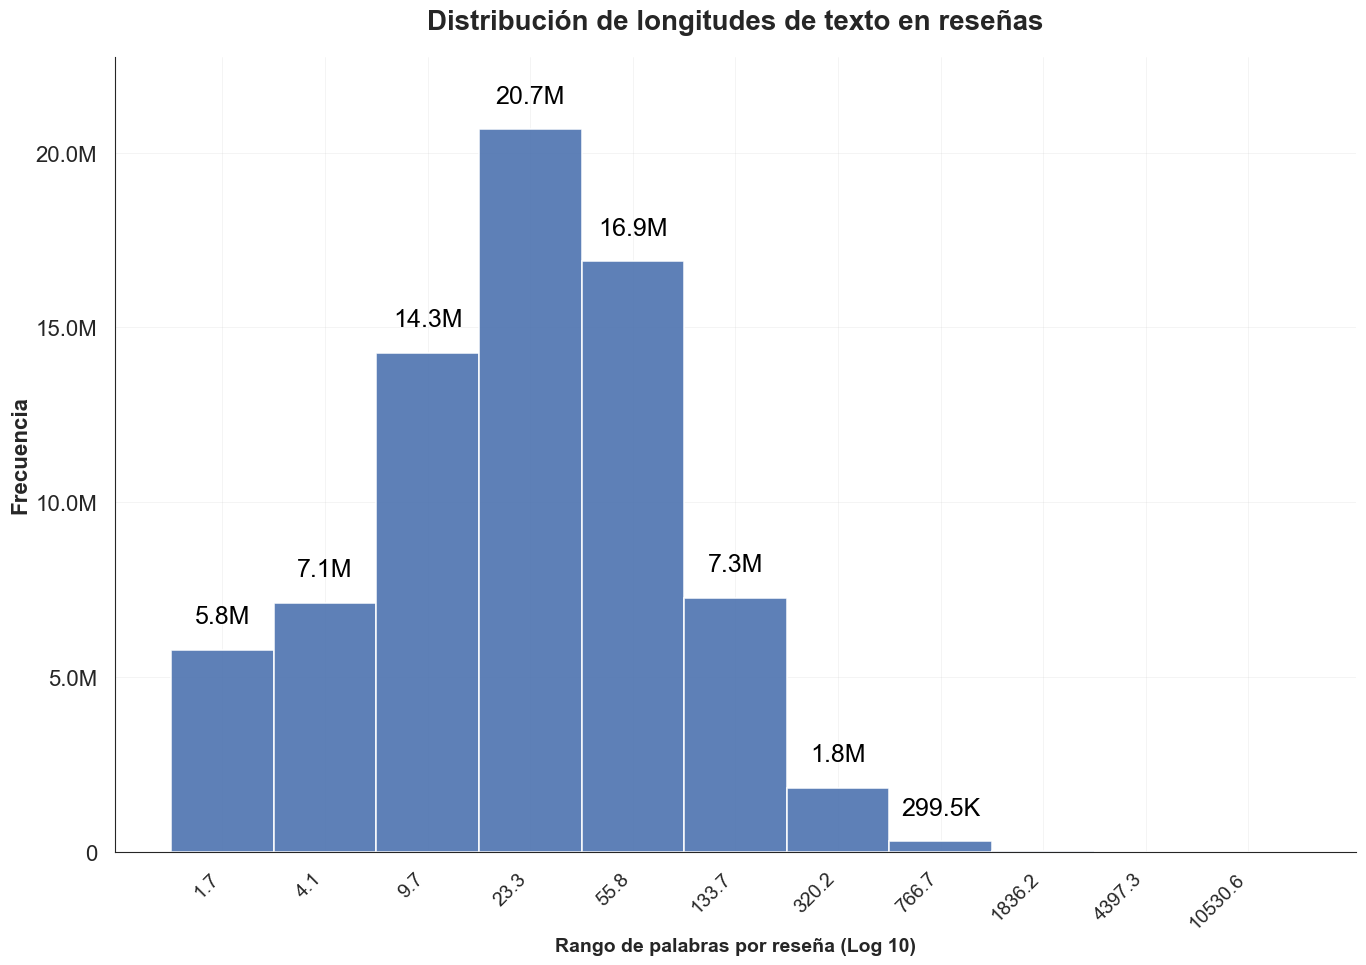

In [97]:
bar_plot_reviews_length_large = BarPlot()
bar_plot_reviews_length_large.prepare_single_show(
    title='Distribución de longitudes de texto en reseñas'
)
bar_plot_reviews_length_large.plot(
    reviews_length_barplot_data_reduced,
    ylabel='Frecuencia', 
    xlabel='Rango de palabras por reseña (Log 10)',
    decimal_points=0,
    is_percentage=False, 
    x_rotation=45, 
    y_rotation=0,
    color="#4c72b0",
    figsize=(14, 10),
    x_font_size=14,
    y_font_size=16,
    title_font_size=20,
    label_font_size=18,
    label_density=0.8,
    rotate_labels=True,
    label_rotation=0,
    rotate_x_labels=True,
    x_label_rotation=45,
    show_x_labels=True,
    x_label_density=1.0,
    bar_width=1.0, 
    use_exponential_labels=False
)


#### Revisión TTR para unificación de textos en reseñas de producto

In [84]:
reviews_clean_words_tokenized_with_id = reviews_clean_words_tokenized.withColumn(
    'review_id', F.row_number().over(Window.orderBy('parent_asin'))
)

In [85]:
reviews_clean_words_tokenized_with_id.count()

74204685

In [86]:
exploded_reviews = reviews_clean_words_tokenized_with_id.withColumn(
    "token", F.explode("review_words")
)
unique_counts_reviews = exploded_reviews.groupBy("review_id").agg(
    F.count("token").alias("token_count"),
    F.countDistinct("token").alias("unique_token_count")
)
meta_items_ttr_reviews = unique_counts_reviews \
    .withColumn("TTR", F.col("unique_token_count") / F.col("token_count"))

In [87]:
if REGENERATE_TABLES:
    (
        meta_items_ttr_reviews.write
            .format('delta')
            .mode('overwrite')
            .option('overwriteSchema', 'true')
            .save(spark_utils.path('meta_items_ttr_reviews'))
    )
meta_items_ttr_reviews = spark.read.format('delta').load(spark_utils.path('meta_items_ttr_reviews'))

In [88]:
meta_items_ttr_reviews.count()

3123482

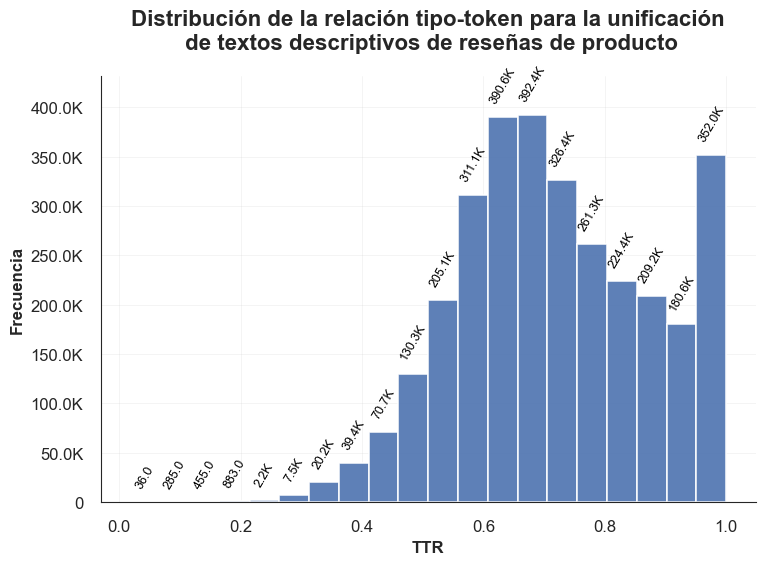

In [89]:
from src.utils.visualization.HistPlot import HistPlot
hist_plot = HistPlot(
    'Distribución de la relación tipo-token para la unificación\n de textos descriptivos de reseñas de producto'
)
hist_plot.plot(
        meta_items_ttr_sample
            .reshape(meta_items_ttr_sample.shape[0])
    ,
    bins = 20,
    xlabel = 'TTR', ylabel = 'Frecuencia', decimal_points = 0
)

#### Revisión de distribución de palabras

In [90]:
print("=== Análisis de Correlación entre Variables de Reseñas ===")
reviews_correlation_data = (
    reviews_clean_words_with_length
        .select(
            F.col('parent_asin'),
            F.col('rating'),
            F.col('helpful_vote').alias('helpful_votes'),
            F.col('clean_words_length').alias('num_words')
        )
        .filter(
            (F.col('rating').isNotNull()) & 
            (F.col('helpful_votes').isNotNull()) & 
            (F.col('num_words') > 0)
        )
)

=== Análisis de Correlación entre Variables de Reseñas ===


In [ ]:
print("\n=== Calculando Correlaciones (Método Corregido) ===")
from pyspark.sql.functions import corr
rating_helpful_corr = reviews_correlation_data.select(corr('rating', 'helpful_votes')).collect()[0][0]
rating_words_corr = reviews_correlation_data.select(corr('rating', 'num_words')).collect()[0][0]
helpful_words_corr = reviews_correlation_data.select(corr('helpful_votes', 'num_words')).collect()[0][0]
print(f"Correlación Rating - Votos Útiles: {rating_helpful_corr:.4f}")
print(f"Correlación Rating - Número de Palabras: {rating_words_corr:.4f}")
print(f"Correlación Votos Útiles - Número de Palabras: {helpful_words_corr:.4f}")
variables = ['rating', 'helpful_votes', 'num_words']
correlation_matrix = np.array([
    [1.0, rating_helpful_corr, rating_words_corr],
    [rating_helpful_corr, 1.0, helpful_words_corr],
    [rating_words_corr, helpful_words_corr, 1.0]
])
correlation_df = pd.DataFrame(
    correlation_matrix,
    index=variables,
    columns=variables
)
print("\nMatriz de Correlación:")
print(correlation_df.round(4))



=== Calculando Correlaciones (Método Corregido) ===
Correlación Rating - Votos Útiles: -0.0117
Correlación Rating - Número de Palabras: -0.0899
Correlación Votos Útiles - Número de Palabras: 0.1147

Matriz de Correlación:
               rating  helpful_votes  num_words
rating         1.0000        -0.0117    -0.0899
helpful_votes -0.0117         1.0000     0.1147
num_words     -0.0899         0.1147     1.0000


In [92]:
correlation_df

,rating,helpful_votes,num_words
rating,1.000000,-0.011673,-0.08988
helpful_votes,-0.011673,1.000000,0.11465
num_words,-0.089880,0.114650,1.00000


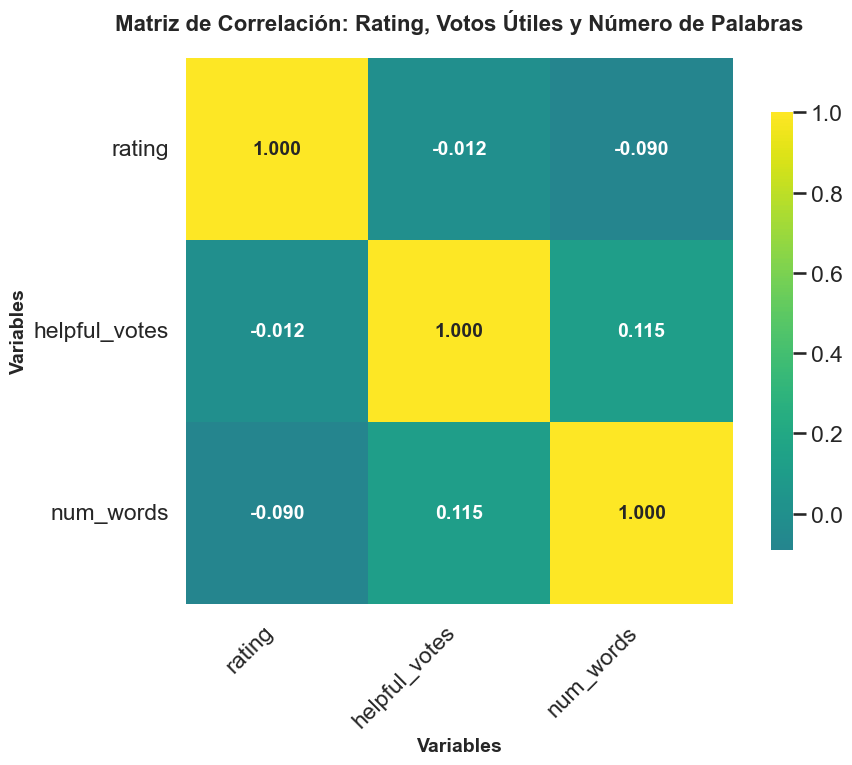


=== Análisis de Correlaciones ===
Correlación Rating - Votos Útiles: -0.0117
Correlación Rating - Número de Palabras: -0.0899
Correlación Votos Útiles - Número de Palabras: 0.1147

=== Interpretación ===
• La correlación entre Rating y Votos Útiles es débil (-0.012)
• La correlación entre Rating y Número de Palabras es débil (-0.090)
• La correlación entre Votos Útiles y Número de Palabras es débil (0.115)


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(
    correlation_df,
    annot=True,
    cmap='viridis',
    center=0,
    square=True,
    fmt='.3f',
    cbar_kws={"shrink": .8},
    annot_kws={'fontsize': 14, 'fontweight': 'bold'}
)
plt.title('Matriz de Correlación: Rating, Votos Útiles y Número de Palabras', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Variables', fontsize=14, fontweight='bold')
plt.ylabel('Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("\n=== Análisis de Correlaciones ===")
print(f"Correlación Rating - Votos Útiles: {correlation_df.loc['rating', 'helpful_votes']:.4f}")
print(f"Correlación Rating - Número de Palabras: {correlation_df.loc['rating', 'num_words']:.4f}")
print(f"Correlación Votos Útiles - Número de Palabras: {correlation_df.loc['helpful_votes', 'num_words']:.4f}")
print("\n=== Interpretación ===")
rating_helpful = correlation_df.loc['rating', 'helpful_votes']
rating_words = correlation_df.loc['rating', 'num_words']
helpful_words = correlation_df.loc['helpful_votes', 'num_words']
if abs(rating_helpful) > 0.3:
    direction = "positiva" if rating_helpful > 0 else "negativa"
    strength = "fuerte" if abs(rating_helpful) > 0.7 else "moderada"
    print(f"• Existe una correlación {strength} {direction} entre Rating y Votos Útiles ({rating_helpful:.3f})")
else:
    print(f"• La correlación entre Rating y Votos Útiles es débil ({rating_helpful:.3f})")
if abs(rating_words) > 0.3:
    direction = "positiva" if rating_words > 0 else "negativa"
    strength = "fuerte" if abs(rating_words) > 0.7 else "moderada"
    print(f"• Existe una correlación {strength} {direction} entre Rating y Número de Palabras ({rating_words:.3f})")
else:
    print(f"• La correlación entre Rating y Número de Palabras es débil ({rating_words:.3f})")
if abs(helpful_words) > 0.3:
    direction = "positiva" if helpful_words > 0 else "negativa"
    strength = "fuerte" if abs(helpful_words) > 0.7 else "moderada"
    print(f"• Existe una correlación {strength} {direction} entre Votos Útiles y Número de Palabras ({helpful_words:.3f})")
else:
    print(f"• La correlación entre Votos Útiles y Número de Palabras es débil ({helpful_words:.3f})")


In [ ]:
print("\n=== Análisis de Correlaciones por Rangos de Rating (Método Corregido) ===")
reviews_by_rating = (
    reviews_correlation_data
        .withColumn(
            'rating_group',
            F.when(F.col('rating') <= 2, 'Bajo (1-2)')
             .when(F.col('rating') == 3, 'Medio (3)')
             .when(F.col('rating') >= 4, 'Alto (4-5)')
             .otherwise('Otro')
        )
        .filter(F.col('rating_group') != 'Otro')
)
rating_groups = ['Bajo (1-2)', 'Medio (3)', 'Alto (4-5)']
for group in rating_groups:
    group_data = reviews_by_rating.filter(F.col('rating_group') == group)
    group_count = group_data.count()
    if group_count > 100:
        print(f"\n--- {group} ({group_count:,} reseñas) ---")
        group_rating_helpful = group_data.select(corr('rating', 'helpful_votes')).collect()[0][0]
        group_rating_words = group_data.select(corr('rating', 'num_words')).collect()[0][0]
        group_helpful_words = group_data.select(corr('helpful_votes', 'num_words')).collect()[0][0]
        print(f"Correlación Rating - Votos Útiles: {group_rating_helpful}")
        print(f"Correlación Rating - Número de Palabras: {group_rating_words}")
        print(f"Correlación Votos Útiles - Número de Palabras: {group_helpful_words}")
    else:
        print(f"\n--- {group} ({group_count:,} reseñas) - Insuficientes datos para análisis ---")
print("\n=== Resumen del Análisis de Correlación ===")
print("• Se analizaron las correlaciones entre Rating, Votos Útiles y Número de Palabras")
print("• Los cálculos se realizaron usando PySpark para manejar grandes volúmenes de datos")
print("• Se incluyó análisis por grupos de rating para identificar patrones específicos")
print("• La matriz de correlación muestra las relaciones lineales entre las variables")



=== Análisis de Correlaciones por Rangos de Rating (Método Corregido) ===

--- Bajo (1-2) (13,433,299 reseñas) ---
Correlación Rating - Votos Útiles: -0.012228509815306121
Correlación Rating - Número de Palabras: 0.08917936604142084
Correlación Votos Útiles - Número de Palabras: 0.0965859166409188

--- Medio (3) (5,183,653 reseñas) ---
Correlación Rating - Votos Útiles: None
Correlación Rating - Número de Palabras: None
Correlación Votos Útiles - Número de Palabras: 0.1298776293555583

--- Alto (4-5) (55,520,324 reseñas) ---
Correlación Rating - Votos Útiles: -0.006303272201327439
Correlación Rating - Número de Palabras: -0.12005114176208881
Correlación Votos Útiles - Número de Palabras: 0.11795936207596833

=== Resumen del Análisis de Correlación ===
• Se analizaron las correlaciones entre Rating, Votos Útiles y Número de Palabras
• Los cálculos se realizaron usando PySpark para manejar grandes volúmenes de datos
• Se incluyó análisis por grupos de rating para identificar patrones es

In [ ]:
reviews_with_products_clean_html = reviews_with_products.withColumn(
    "clean_text",
    F.regexp_replace(F.col("review_text"), "<[^>]+>", " ")
)
tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")
tokenized = tokenizer.transform(reviews_with_products_clean_html)
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
reviews_with_products_clean_words = remover.transform(tokenized)

In [ ]:
if REGENERATE_TABLES:
    (
    reviews_with_products_clean_words.write
        .format('delta')
        .mode('overwrite')
        .save(spark_utils.path('reviews_with_products_clean_words'))
    )
reviews_with_products_clean_words = spark.read.format('delta').load(spark_utils.path('reviews_with_products_clean_words'))

In [ ]:
reviews_with_products_clean_words_length = (
    reviews_with_products_clean_words
        .withColumn(
            'clean_words_length',
            F.size(F.col('filtered'))
        )
        .filter(F.col('clean_words_length') > F.lit(0))
)

### Palabras por categoría

In [ ]:
filtered_reviews_with_products_collected_words = (
    reviews_with_products_clean_words.withColumn("expanded_words", F.explode("filtered"))
      .groupBy("main_category", "expanded_words")
      .agg(F.count('*').alias('count'))
)
if REGENERATE_TABLES:
    (
        filtered_reviews_with_products_collected_words.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('filtered_reviews_with_products_collected_words'))
    )
filtered_reviews_with_products_collected_words = spark.read.format('delta').load(spark_utils.path('filtered_reviews_with_products_collected_words'))

In [ ]:
filtered_reviews_with_products_collected_words_top_categories = (
    filtered_reviews_with_products_collected_words
        .groupBy('main_category')
        .agg(F.sum(F.col('count')).alias('count'))
        .filter(F.length(F.col('main_category')) > 0)
        .withColumn(
            'category_id',
            F.row_number().over(
                Window
                    .orderBy(
                        F.col('count').desc()
                    )
            )
        )
)

In [ ]:
filtered_reviews_with_products_collected_words_top_keys = (
    filtered_reviews_with_products_collected_words
        .filter(F.length(F.col('expanded_words')) > 0)
        .withColumn(
            'word_id', F.row_number().over(
                Window
                    .partitionBy('main_category')
                    .orderBy(
                        F.col('count').desc()
                    )
            )
        ).alias('A')
        .join(
            filtered_reviews_with_products_collected_words_top_categories.alias('B')
                .filter(
                    F.col('category_id') <= F.lit(10)
                ),
            F.col('A.main_category') == F.col('B.main_category'),
            'inner'
        )
        .filter(
            (F.col('word_id') <= 30)
        )
        .select(
            F.col('A.main_category').alias('category'),
            F.col('expanded_words').alias('word'),
            F.col('A.count').alias('count'),
        )
)

In [ ]:
mem_filtered_reviews_with_products_collected_words_top_keys = (
    filtered_reviews_with_products_collected_words_top_keys.toPandas()
)

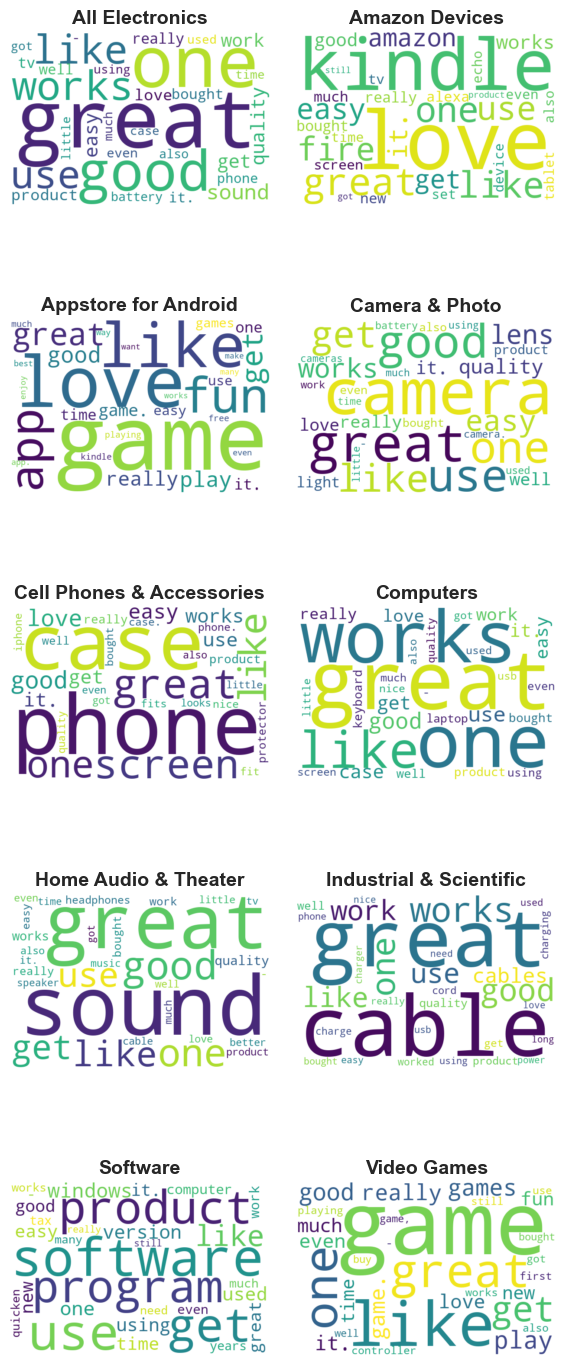

In [ ]:
from src.utils.visualization import WordCloudPlot
word_cloud = WordCloudPlot()
word_cloud.prepare_matrix_show(
    'Distribución logarítimica del tamaño de descripción de reseña de usuario'
)
word_cloud.plot(
    mem_filtered_reviews_with_products_collected_words_top_keys, cols = 2,
    cols_size = 3, rows_size = 3
)

#### Palabras por puntaje de reseña, términos mas usados para comentarios positivos y negativos

In [ ]:
filtered_reviews_with_products_collected_words_with_rating = (
    reviews_with_products_clean_words.withColumn("expanded_words", F.explode("filtered"))
      .groupBy("main_category", "expanded_words", "rating")
      .agg(F.count('*').alias('count'))
)
if REGENERATE_TABLES:
    (
        filtered_reviews_with_products_collected_words_with_rating.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('filtered_reviews_with_products_collected_words_with_rating'))
    )
filtered_reviews_with_products_collected_words_with_rating = spark.read.format('delta').load(spark_utils.path('filtered_reviews_with_products_collected_words_with_rating'))

In [ ]:
filtered_reviews_with_products_ratings_collected_words_top_categories = (
    filtered_reviews_with_products_collected_words_with_rating
        .groupBy('main_category')
        .agg(F.sum(F.col('count')).alias('count'))
        .filter(F.length(F.col('main_category')) > 0)
        .withColumn(
            'category_id',
            F.row_number().over(
                Window
                    .orderBy(
                        F.col('count').desc()
                    )
            )
        )
)

In [ ]:
filtered_reviews_with_products_collected_words_with_rating_top_keys = (
    filtered_reviews_with_products_collected_words_with_rating
        .filter(
            (F.length(F.col('expanded_words')) > 0) &
            (F.col('rating').isNotNull())
        )
        .withColumn(
            'word_id', F.row_number().over(
                Window
                    .partitionBy('main_category', 'rating')
                    .orderBy(
                        F.col('count').desc()
                    )
            )
        ).alias('A')
        .join(
            filtered_reviews_with_products_ratings_collected_words_top_categories.alias('B')
                .filter(
                    F.col('category_id') <= F.lit(5)
                ),
            F.col('A.main_category') == F.col('B.main_category'),
            'inner'
        )
        .filter(
            (F.col('word_id') <= 30)
        )
        .withColumn(
            'category',
            F.concat(F.col('A.main_category'), F.lit(' '), F.col('rating'))
        )
        .select(
            F.col('category').alias('category'),
            F.col('expanded_words').alias('word'),
            F.col('A.count').alias('count'),
        )
)

In [ ]:
mem_filtered_reviews_with_products_collected_words_with_rating_top_keys = (
    filtered_reviews_with_products_collected_words_with_rating_top_keys.toPandas()
)

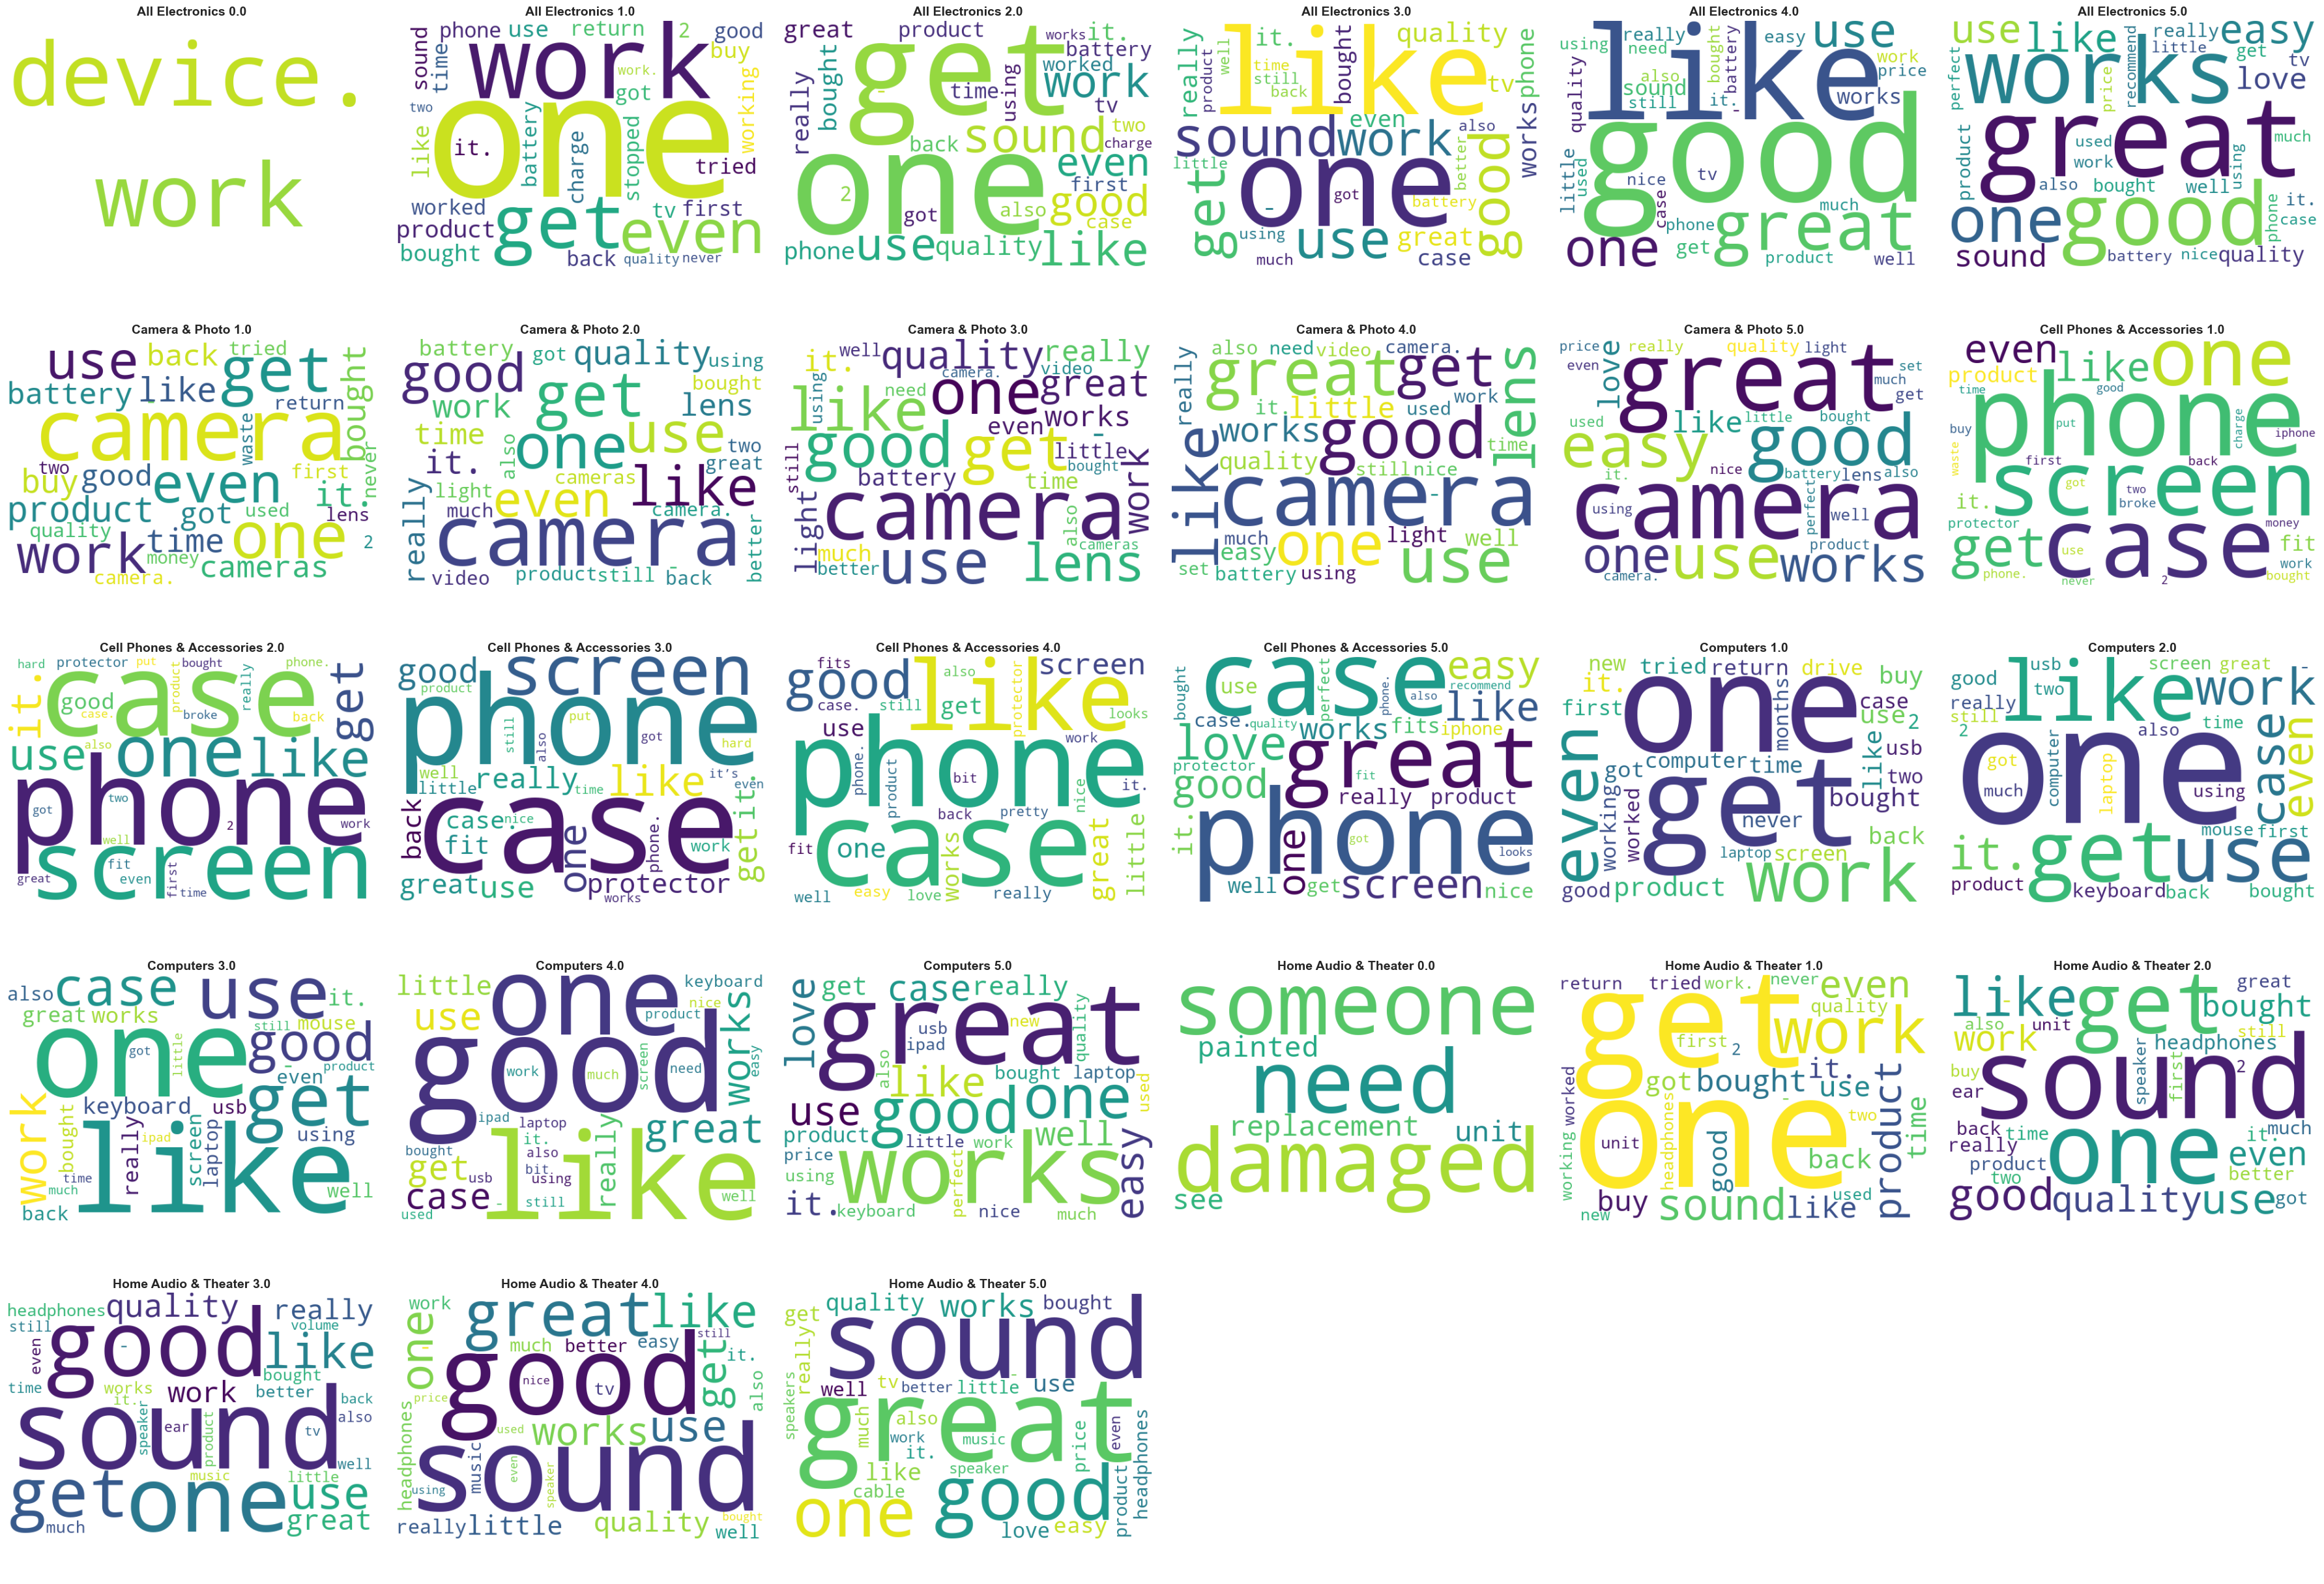

In [ ]:
from src.utils.visualization import WordCloudPlot
word_cloud = WordCloudPlot()
word_cloud.prepare_matrix_show(
    'Distribución logarítimica del tamaño de descripción de reseña de usuario por calificaciòn'
)
word_cloud.plot(
    mem_filtered_reviews_with_products_collected_words_with_rating_top_keys, cols = 6
)

### Distribución de cantidad de reseñas por producto

In [ ]:
reviews_with_products_count = (
    reviews_with_products
        .groupBy('parent_asin')
        .agg(F.count('*').alias('count'))
        .filter(F.col('count') > F.lit(0))
)

In [ ]:
reviews_with_products_category_count_additional = (
    reviews_with_products_count
        .agg(
            F.min('count').alias('min_reviews_count'),
            F.max('count').alias('max_reviews_count'),
            F.mean('count').alias('mean_reviews_count'),
            F.std('count').alias('str_reviews_count'),
            F.median('count').alias('median_reviews_count'),
            F.mode('count').alias('mode_reviews_count')
        )
        .toPandas()
        .values
)

In [ ]:
min, max, mean, std, median, mode = reviews_with_products_category_count_additional.tolist()[0]

In [ ]:
min, max, mean, std, median, mode

(1.0, 178239.0, 23.747049407385315, 297.0711457431049, 2.0, 1.0)

In [ ]:
reviews_with_products_count_sample = (
    reviews_with_products_count
        .select('count')
        .toPandas()
        .values
)

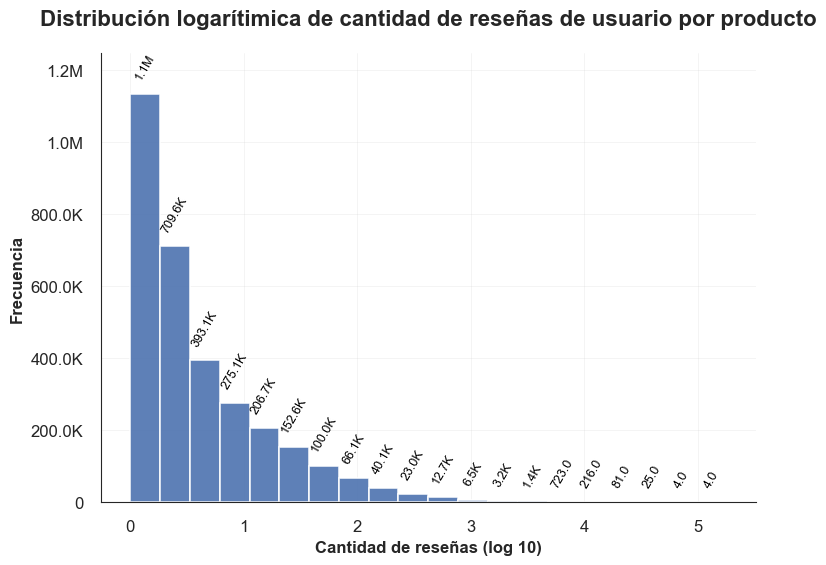

In [ ]:
from src.utils.visualization.HistPlot import HistPlot
hist_plot = HistPlot(
    'Distribución logarítimica de cantidad de reseñas de usuario por producto'
)
hist_plot.plot(
    np.log10(
        reviews_with_products_count_sample
            .reshape(reviews_with_products_count_sample.shape[0])
    ),
    bins = 20,
    xlabel = 'Cantidad de reseñas (log 10)', ylabel = 'Frecuencia', decimal_points = 0
)

Cantidad de productos con al menos 10 reseñas

In [ ]:
reviews_with_products_count.count()

3124796

In [ ]:
(
    reviews_with_products_count
        .filter(F.col('count') > 1)
).count()

1991030

In [ ]:
reviews_with_products_count_least_10 = (
    reviews_with_products_count
        .filter(F.col('count') > 1)
).count()

In [ ]:
reviews_with_products_count_least_10.count()

984541

Cantidad de reseñas para productos con al menos 10 reseñas

In [ ]:
reviews_with_products_least_10 = (
    reviews_with_products.alias('A')
        .join(
            reviews_with_products_count_least_10.alias('B'),
            F.col('A.parent_asin') == F.col('B.parent_asin'),
            'inner'
        )
        .select(
            F.col('A.*')
        )
)

Cantidad de productos con al menos 10 reseñas

In [ ]:
reviews_with_products_least_10.select('parent_asin').distinct().count()

984541